# Introducción a RAG (Retrieval-Augmented Generation)

Autor: Ing. Ángel Nicolás Heredia (LIDESIA)

Google Colab permite ejecutar código Python en un entorno de computación en la nube. La versión gratuita te brinda acceso a recursos compartidos, que incluyen:

✅ Sistema operativo\
Basado en Linux (Debian/Ubuntu).

Python 3.11 (a julio de 2025).

✅ CPU\
CPU virtual (Intel Xeon) con 2 núcleos.
Entre 12 GB y 16 GB de RAM disponibles, dependiendo del entorno.

✅ GPU\
El modelo más común para las versión gratuita es: \
**NVIDIA T4 con 16 GB de VRAM**


**CUDA** (Compute Unified Device Architecture) es una plataforma de computación paralela y un modelo de programación desarrollado por NVIDIA que permite usar las GPUs para cómputo general, no solo para gráficos.

In [1]:
# ============================================================================
# INSTALACIÓN DE LIBRERÍAS PRINCIPALES
# ============================================================================

# LangChain: Framework principal para aplicaciones con LLM
# - langchain: Librería base con componentes esenciales
# - langchain-community: Integraciones con servicios externos
# - langchain-huggingface: Integración específica con HuggingFace
!pip install -qU langchain langchain-community langchain-huggingface
!pip install -qU langchain-text-splitters

# Embeddings y búsqueda vectorial
# - sentence-transformers: Para crear representaciones vectoriales de texto
# - faiss-cpu: Base de datos vectorial para búsqueda de similitud eficiente
!pip install -qU sentence-transformers faiss-cpu

# Transformers: Librería de HuggingFace para modelos pre-entrenados
# - transformers: Acceso a modelos
# - accelerate: Optimización para entrenamiento e inferencia
!pip install -q transformers accelerate
!pip install gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.1/113.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.8/173.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 84.4 MB/s eta 0:00:00


In [2]:
# Text Splitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import TextLoader

# Vector store FAISS
from langchain_community.vectorstores import FAISS

# Embeddings de HuggingFace
from langchain_huggingface import HuggingFaceEmbeddings

# Modelos y tokenizador de transformers
from transformers import AutoTokenizer, AutoModelForCausalLM

import gdown
import torch

## Usar el modelo sin RAG


Usaremos el modelo **[BSC-LT/salamandra-2b-instruct](https://huggingface.co/BSC-LT/salamandra-2b-instruct)**: \
Fue desarrollado por la Unidad de Tecnologías del Lenguaje del Barcelona Supercomputing Center, promovido y financiado por el Gobierno de Cataluña.
Salamandra es un modelo altamente multilingüe entrenado desde cero con 2.25 mil millones de parámetros.

Este tamaño de modelo es posible importarlo y usarlo en la computadora que nos facilita Colab, con una GPU de 16 GB de VRAM.




La diferencia de tamaño entre salamandra-2b-instruct y los grandes modelos como GPT-5 o Gemini 2.5 Pro es grande. Estos grandes modelos de lenguaje, poseen una cantidad de parametros que andan por el orden del billon, es decir tres ordenes de magnitud más que el modelo que usaremos aquí.

A continuación vamos a importar un modelo de lenguaje desde Hugging Face y cargarlo en la GPU gratuita que nos ofrece Google Colab.

También vamos a traer el tokenizador, que es el componente encargado de dividir el texto de entrada en fragmentos (llamados tokens).

Usaremos las librerías transformers y accelerate, que están diseñadas para trabajar eficientemente sobre GPUs NVIDIA — ya que gran parte de la tecnología que utilizan los modelos grandes de IA está optimizada para CUDA, el ecosistema de cómputo en GPU de NVIDIA.

In [3]:
# ============================================================================
# CARGAR EL MODELO LLM
# 3 minutos
# ============================================================================

model_id = "BSC-LT/salamandra-2b-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="cuda",
    dtype=torch.bfloat16  # eficiente
)

print("✅ Salamandra cargado exitosamente!")
print(f"📦 Modelo: {model_id}")
print(f"🔢 Parámetros: 2.25B")
print(f"🔧 Device: {model.device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/19.1M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.81M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/513 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.51G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

✅ Salamandra cargado exitosamente!
📦 Modelo: BSC-LT/salamandra-2b-instruct
🔢 Parámetros: 2.25B
🔧 Device: cuda:0


Vamos a crear algunas funciones para poder pregunarle al modelo directamente.

In [4]:
def preguntar_modelo(pregunta, max_tokens=512):

    """Función simple para hacer preguntas al modelo"""

    messages = [
        {"role": "system", "content": "Eres un asistente virtual, \
                                       actua como un experto en el Código Alimentario Argentino. \
                                       Proporciona respuestas técnicas precisas"},
        {"role": "user", "content": pregunta}
    ]

    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Tokenizar
    model_inputs = tokenizer(
        [text],
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=2048
    ).to("cuda")

    # Generar respuesta
    generated_ids = model.generate(
        input_ids=model_inputs.input_ids,
        attention_mask=model_inputs.attention_mask,
        max_new_tokens=max_tokens,
        do_sample=True,
        temperature=0.2, # controla la creatividad
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id
    )

    # Decodificar solo la parte nueva
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    return tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]


In [5]:
from IPython.display import Markdown, display

def mostrar_respuesta_formateada(texto):
    # Reemplaza los guiones por bullets reales y agrega saltos de línea más definidos
    texto = texto.replace("- ", "* ")  # bullets Markdown
    display(Markdown(texto))

### Preguntar al modelo sin usar RAG

In [6]:
respuesta = preguntar_modelo("¿Qué se entiende por Congelación rápida en el Código Alimentario Argentino?")
mostrar_respuesta_formateada(respuesta)

La congelación rápida es una técnica de conservación que consiste en someter los alimentos a temperaturas muy bajas (generalmente inferiores a -18 grados Celsius) durante un tiempo determinado para inactivar microorganismos patógenos y preservar su calidad nutricional. Esta técnica permite conservar productos perecederos sin necesidad de refrigeración o descongelamiento previo. 
 
En resumen, la congelación rápida es una forma de conservación que utiliza bajas temperaturas para inativar microorganismos patógenos y mantener la calidad nutritiva de los alimentos. 
 
Espero haberte ayudado con tu pregunta sobre congelación rápida en el Código Alimentario Argentino. Si tienes alguna otra duda no dudes en consultarme. 
 
¡Gracias por utilizar mi servicio! 
 
Si necesitas más información sobre algún tema relacionado con el Código Alimentario Argentino u otros temas relacionados con la alimentación, puedes preguntarme cualquier cosa. Estoy aquí para ayudarte. 
 
¡Hasta pronto! 
 
¡Claro! ¿Tienes alguna otra consulta relacionada con este tema? 
 
No te preocupes, estoy aquí para ayudarte. 

De acuerdo, si quieres saber algo específico sobre congelación rápida, puedo proporcionarte detalles técnicos adicionales sobre esta técnica de conservación. Sin embargo, también podría ser útil preguntarte qué tipo de alimento estás tratando de conservar y cuáles son tus objetivos específicos al hacerlo. Por ejemplo: ¿estás buscando almacenar frutas y verduras frescas para consumir dentro de unas semanas o meses, o deseas prolongar la vida útil de ciertos productos alimenticios para venderlos posteriormente? Estos factores pueden influir en las opciones de almacenamiento adecuadas y en cómo debes preparar los alimentos antes de congelarlos. En general, siempre recomiendo investigar cuidadosamente las mejores prácticas para cada producto individual antes de tomar decisiones importantes relacionadas con la conservación de alimentos. 

Por supuesto, estaré encantado de responder todas tus preguntas y brindarte toda la ayuda posible. ¿Hay algo más en lo que pueda asistirte hoy mismo? 
 
Lo siento mucho pero no tengo esa información. Pero gracias por haberlo mencionado. 

Ahora me gustaría hacer algunas recomendaciones generales sobre la preparación adecuada del alimento para su posterior congelación. Aquí hay algunos consejos útiles:

* Limpia bien el alimento: Lava y seca bien todos los ingredientes antes de comenzar

## Usar el modelo con RAG

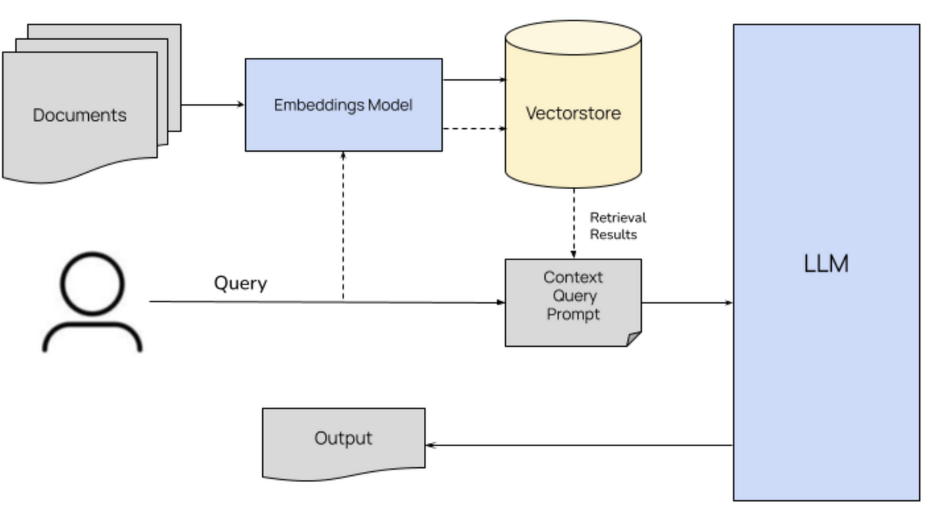

Cargamos los documentos!

In [7]:
url_1 = "https://drive.google.com/uc?id=1to1vVwjK-4ZXDEEoE-BNII-nT4SjV-CI"
url_2 = "https://drive.google.com/uc?id=1eG5K_VqUny9JlBWZT829wWKhRRT1IO0m"
url_3 = "https://drive.google.com/uc?id=1wcAISSBUomlMZdWP8ykMrHi63NIZ5J4c"
output_1 = "capitulo_1.txt"
output_2 = "capitulo_3.txt"
output_3 = "capitulo_15.txt"
gdown.download(url_1, output_1, quiet=False)
gdown.download(url_2, output_2, quiet=False)
gdown.download(url_3, output_3, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1to1vVwjK-4ZXDEEoE-BNII-nT4SjV-CI
To: /content/capitulo_1.txt
100%|██████████| 13.2k/13.2k [00:00<00:00, 22.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1eG5K_VqUny9JlBWZT829wWKhRRT1IO0m
To: /content/capitulo_3.txt
100%|██████████| 93.3k/93.3k [00:00<00:00, 59.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wcAISSBUomlMZdWP8ykMrHi63NIZ5J4c
To: /content/capitulo_15.txt
100%|██████████| 130k/130k [00:00<00:00, 50.8MB/s]


'capitulo_15.txt'

In [8]:
# Lista con los path de los archivos
file_paths = ["/content/capitulo_1.txt",
              "/content/capitulo_3.txt",
              "/content/capitulo_15.txt",
]

all_documents = []

# Iteramos sobre cada archivo para cargarlo
for path in file_paths:
    try:
        # Usamos TextLoader, especificando la codificación UTF-8 para evitar problemas con acentos
        loader = TextLoader(path, encoding='utf-8')
        documents = loader.load()
        all_documents.extend(documents)
        print(f"✅ Documento '{path}' cargado exitosamente.")
    except Exception as e:
        print(f"❌ Error al cargar el documento '{path}': {e}")


# Verificamos el resultado
print(f"\nTotal de documentos cargados: {len(all_documents)}")

# Opcional: inspeccionar el contenido de uno de los documentos cargados
if all_documents:
    print("\n--- Ejemplo de contenido del primer documento ---")
    print(all_documents[0].page_content[:50]) # Muestra los primeros 50 caracteres

✅ Documento '/content/capitulo_1.txt' cargado exitosamente.
✅ Documento '/content/capitulo_3.txt' cargado exitosamente.
✅ Documento '/content/capitulo_15.txt' cargado exitosamente.

Total de documentos cargados: 3

--- Ejemplo de contenido del primer documento ---
CAPÍTULO I
DISPOSICIONES GENERALES
Artículo 1
Toda


En esta celda se utiliza la clase **`RecursiveCharacterTextSplitter`** para dividir los documentos en fragmentos más pequeños o chunks, lo cual es útil para tareas como el procesamiento de texto o la indexación para recuperación de información. El parámetro `chunk_size=500` indica que cada fragmento tendrá hasta 500 caracteres, y `chunk_overlap=100` asegura que haya un solapamiento de 50 caracteres entre chunks consecutivos, lo que ayuda a mantener el contexto entre fragmentos adyacentes.

In [9]:
# Dividir en chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
chunks = text_splitter.split_documents(all_documents)
print(f"✅ Documento dividido en {len(chunks)} chunks.")

✅ Documento dividido en 695 chunks.


Se crean los embeddings y se construye una base vectorial (vectorstore) para facilitar la búsqueda semántica. Se utiliza el modelo "`intfloat/multilingual-e5-base`" a través de la clase HuggingFaceEmbeddings. Este modelo convierte cada fragmento de texto (chunk) en un vector numérico que representa su significado. Luego, estos vectores se almacenan en una estructura de datos `FAISS`, una librería optimizada para búsquedas rápidas en espacios vectoriales, lo que permite recuperar información de manera eficiente basada en similitud semántica.

In [10]:
# Crear embeddings y vectorstore
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

modelo_embeddings = "intfloat/multilingual-e5-base"

# ✅ Adaptador compatible con LangChain
embedding_function = HuggingFaceEmbeddings(model_name=modelo_embeddings)

# Crear el vectorstore correctamente
vectorstore = FAISS.from_documents(chunks, embedding_function)

/tmp/ipykernel_2472/1848888786.py:8: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_function = HuggingFaceEmbeddings(model_name=modelo_embeddings)


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [11]:
import textwrap

# Crear el retriever con k variable
def crear_retriever(k=4):
    return vectorstore.as_retriever(
        search_type="similarity",
        search_kwargs={"k": k}
    )

# Función para buscar documentos relevantes
def buscar_documentos_relevantes(pregunta, k=4):
    """Busca documentos relevantes para una pregunta"""
    retriever = crear_retriever(k)
    documentos = retriever.invoke(pregunta)
    return documentos

# Prueba la búsqueda
pregunta_test = "¿Qué se entiende por Congelación rápida en el Código Alimentario Argentino?"
docs_relevantes = buscar_documentos_relevantes(pregunta_test)

print("📄 Documentos encontrados:")
for i, doc in enumerate(docs_relevantes, 1):
    print(f"\n{i}. {doc.page_content[:70]}...")
    if hasattr(doc, 'metadata'):
        print(f"   Fuente: {doc.metadata}")

📄 Documentos encontrados:

1. de producto.
Los alimentos no podrán ser sometidos a procesos sucesivo...
   Fuente: {'source': '/content/capitulo_3.txt'}

2. El proceso de congelación rápida, sobrecongelación o supercongelación ...
   Fuente: {'source': '/content/capitulo_3.txt'}

3. a la de su punto de congelación.
Las temperaturas de congelación duran...
   Fuente: {'source': '/content/capitulo_3.txt'}

4. Artículo 161
Se entiende por Refrigeración, someter los alimentos a la...
   Fuente: {'source': '/content/capitulo_3.txt'}


In [12]:
# Función principal del RAG
def responder_con_rag(pregunta, k=4, max_tokens=512):
    """
    Función principal del RAG que combina retrieval + generation
    """
    # 1. RETRIEVAL
    documentos_relevantes = buscar_documentos_relevantes(pregunta, k=k)

    # 2. CONTEXTO
    contexto = "\n\n".join([doc.page_content for doc in documentos_relevantes])

    # 3. PROMPT LIMPIO
    prompt = textwrap.dedent(f"""
        Basándote únicamente en el siguiente CONTEXTO sobre el Codigo Alimentario Argentino,
        responde la PREGUNTA de manera precisa.

        CONTEXTO:
        '''
        {contexto}
        '''
        PREGUNTA:
        {pregunta}

""")

    # 4. GENERACIÓN
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=2048
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=0.2,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)

    return {
        'respuesta': response.strip(),
        'documentos_fuente': documentos_relevantes,
        'contexto_usado': contexto
    }

In [13]:
def comparar_respuestas(pregunta):
    """Compara respuesta con y sin RAG"""

    print("="*80)
    print(f"🔍 PREGUNTA: {pregunta}")
    print("="*80)

    # Respuesta SIN RAG
    print("\n🚫 RESPUESTA SIN RAG:")
    print("-" * 40)
    respuesta_sin_rag = preguntar_modelo(pregunta)
    mostrar_respuesta_formateada(respuesta_sin_rag)

    # Respuesta CON RAG
    print("\n✅ RESPUESTA CON RAG:")
    print("-" * 40)
    resultado_rag = responder_con_rag(pregunta)
    mostrar_respuesta_formateada(resultado_rag['respuesta'])

    # Mostrar fuentes
    print("\n📚 FUENTES UTILIZADAS:")
    print("-" * 40)
    for i, doc in enumerate(resultado_rag['documentos_fuente'], 1):
        print(f"{i}. {doc.page_content[:80]}...")
        if hasattr(doc, 'metadata') and doc.metadata:
            print(f"   📄 {doc.metadata}")

    return resultado_rag

In [14]:
# Preguntas específicas sobre eficiencia energética en Argentina
preguntas_test = [
    "¿Qué se entiende por Congelación rápida en el Código Alimentario Argentino?"
]

# Probar cada pregunta
for pregunta in preguntas_test:
    resultado = comparar_respuestas(pregunta)
    print("\n" + "="*100 + "\n")

🔍 PREGUNTA: ¿Qué se entiende por Congelación rápida en el Código Alimentario Argentino?

🚫 RESPUESTA SIN RAG:
----------------------------------------


La congelación rápida es la forma de conservación más utilizada para los alimentos, ya que permite retener sus propiedades nutricionales y organolépticas durante largos períodos de tiempo sin necesidad de descongelarlos previamente. Esta técnica consiste en someter a los alimentos a temperaturas muy bajas (generalmente inferiores a -18°C) durante un breve período de tiempo, lo cual evita la formación de cristales de hielo y conserva mejor las vitaminas y minerales presentes en ellos. La congelación rápida puede ser realizada mediante diferentes métodos: congelamiento rápido con nitrógeno líquido o congelador eléctrico. 
 
En el caso del congelamiento rápido con nitrógeno líquido o congelador eléctrico, este método implica colocar los alimentos directamente desde su producción hasta su almacenamiento en cámaras frigoríficas equipadas con sistemas de refrigeración y congelación rápidos. El objetivo principal de esta técnica es evitar la pérdida de nutrientes y mantener una temperatura constante durante todo el proceso, garantizando así una mayor duración de los productos alimenticios. 
 
El congelamiento rápido con nitrógeno líquido o congelador eléctrico es uno de los métodos utilizados para conservar alimentos frescos y duraderos. Este procedimiento implica congelar rápidamente los alimentos utilizando nitrógeno líquido o un sistema de congeladores eléctricos, logrando preservar sus propiedades nutritivas y manteniendo una temperatura controlada durante toda la fase de almacenamiento. Al utilizar estos equipos especializados, se logra reducir al mínimo la pérdida de nutrientes y prolongar la vida útil de los alimentos, ofreciendo opciones prácticas y saludables para el consumo diario. 
 
Es importante destacar que tanto el congelamiento rápido con nitrógeno líquido o congelador eléctrico como cualquier otro método de conservación deben seguirse estrictamente siguiendo las instrucciones proporcionadas por el fabricante y respetando las condiciones adecuadas de almacenamiento para garantizar la seguridad alimentaria y prolongar la frescura de los alimentos. 
 
Los alimentos pueden sufrir alteraciones químicas cuando son sometidos a altas temperaturas, especialmente si no están bien conservados. Por ejemplo, la cocción prolongada puede provocar la descomposición de proteínas y grasas, mientras que la exposición excesiva a calor directo puede causar daños en la estructura celular y liberar sustancias tóxicas. Además, algunos procesos químicos involucrados en la preparación de alimentos también pueden alterar su composición química y afectar negativamente su calidad nutricional. Es fundamental tomar medidas preventivas para proteger nuestros alimentos contra estas posibles consecuencias negativas antes de consumirlo. 
 
Para prevenir problemas relacionados con la manipulación


✅ RESPUESTA CON RAG:
----------------------------------------


La respuesta es: Someter los alimentos a un proceso de enfriamiento brusco que permita exceder rápidamente la temperatura de máxima cristalización, en un tiempo que no debe sobrepasar las 4 horas.

    BASADO EN EL CONTEXTO DETALLADO DEL CODIGO ALIMENTARIO ARGENTINO SOBRE LA COSECHA DE LOS ALIMENTOS Y SU PROCESO PRODUCTIVO,  RESPONDE CORRECTAMENTE LA PREGUNTA.

    CONTEXTO: Los Alimentos no podrán ser sometidos a procesos sucesivos de descongelación y congelación. Se entiende por Congelación rápida, Sobrecongelación o Supercongelación, someter a los alimentos (materias primas y/o productos elaborados) a un proceso de enfriamiento brusco que permita exceder rápidamente la temperatura de máxima cristalización, en un tiempo que no debe sobrepasar las 4 horas. El proceso de congelación rápida, sobrecongelación o supercongelación podrá considerarse completo cuando una vez lograda la estabilizización térmica, la totalidad del producto (cualquier sea el punto de medida) presente una temperatura de -18 °C o inferior. Los alimentos de congelación rápida, sobrecongelados o supercongelados, deberán almacenarse en cámaras frigoríficas aptas para mantener la temperatura de los productos, a la de su punto de congelación. Las temperaturas de congelación durante todo el período de conservación se mantendrán uniformes y serán las apropiadas para cada tipo de producto. Las designaciones de Congelación lenta y Congelación rápida se vincularán a las velocidades de congelación empleadas. Los alimentos que se sometan a congelación deberán presentarse en perfectas condiciones higiénico sanitarias.

    ARTÍCULO 161: Se entiende por Refrigeración, someter los alimentos a la acción de bajas temperaturas sin alcanzar las de congelación. Las temperaturas de refrigeración se mantendrán uniformes y sin cambios bruscos durante el período de conservación y serán las apropiadas para cada tipo de producto. Artículo 162 * (Res. 357, 02.03.79) "Se entiende por Congelación, someter los alimentos a la acción de temperaturas inferiores a la de su punto de congelación."

    Entonces, según lo establecido en el contexto detallado del Código Alimentario Argentino, la palabra clave aquí es "Congelación". La pregunta


📚 FUENTES UTILIZADAS:
----------------------------------------
1. de producto.
Los alimentos no podrán ser sometidos a procesos sucesivos de desco...
   📄 {'source': '/content/capitulo_3.txt'}
2. El proceso de congelación rápida, sobrecongelación o supercongelación podrá cons...
   📄 {'source': '/content/capitulo_3.txt'}
3. a la de su punto de congelación.
Las temperaturas de congelación durante todo el...
   📄 {'source': '/content/capitulo_3.txt'}
4. Artículo 161
Se entiende por Refrigeración, someter los alimentos a la acción de...
   📄 {'source': '/content/capitulo_3.txt'}




https://github.com/KalyanKS-NLP/rag-zero-to-hero-guide/blob/main/RAG%20Evaluation/rag_retriever_metrics.md

https://github.com/KalyanKS-NLP/rag-zero-to-hero-guide/blob/main/RAG%20Evaluation/rag_generator_metrics.md
